In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
# Set visual style
sns.set_theme(style="whitegrid")

In [18]:
# Load the built-in Titanic dataset from Seaborn
df = sns.load_dataset('titanic')

print("Data loaded successfully! Here are the first 5 rows:")
display(df.head())

Data loaded successfully! Here are the first 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [19]:
print("\n--- Dataset Info ---")
df.info()

print("\n--- Statistical Summary of Numeric Columns ---")
display(df.describe())

print("\n--- Missing Values Check ---")
print(df.isnull().sum()[df.isnull().sum() > 0])


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

--- Statistical Summary of Numeric Columns ---


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



--- Missing Values Check ---
age            177
embarked         2
deck           688
embark_town      2
dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2656\2249095561.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='survived', palette='Set2', ax=axes[1])


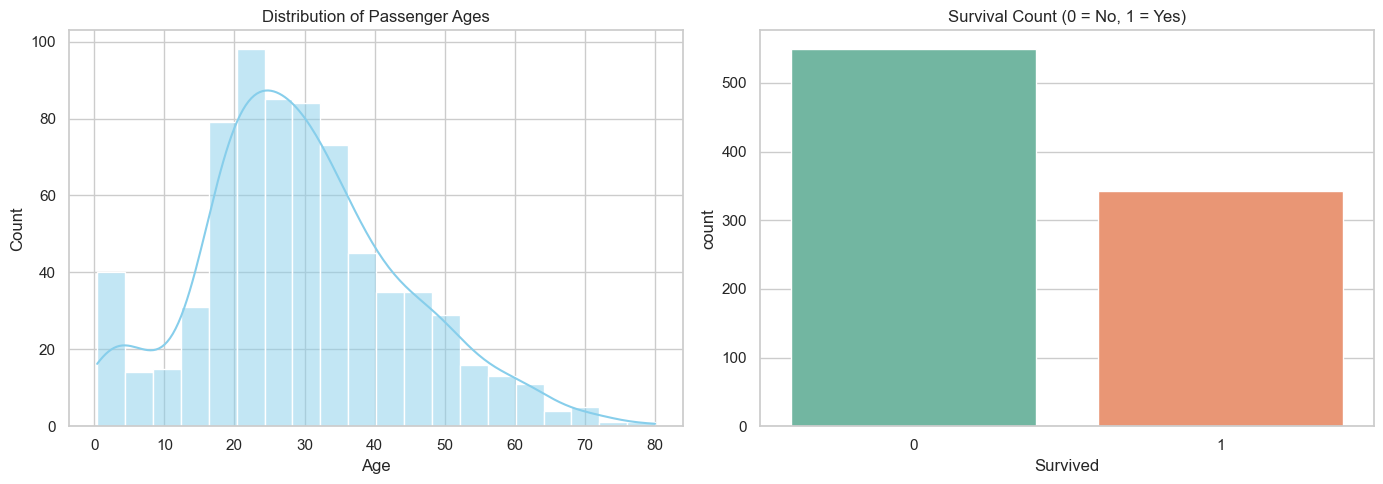

In [20]:
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Age Distribution
sns.histplot(df['age'].dropna(), kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribution of Passenger Ages')
axes[0].set_xlabel('Age')

# Plot 2: Survival Count
sns.countplot(data=df, x='survived', palette='Set2', ax=axes[1])
axes[1].set_title('Survival Count (0 = No, 1 = Yes)')
axes[1].set_xlabel('Survived')

plt.tight_layout()
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2656\748913509.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='sex', y='survived', palette='pastel', ax=axes[0], errorbar=None)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2656\748913509.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='class', y='survived', palette='muted', ax=axes[1], errorbar=None)


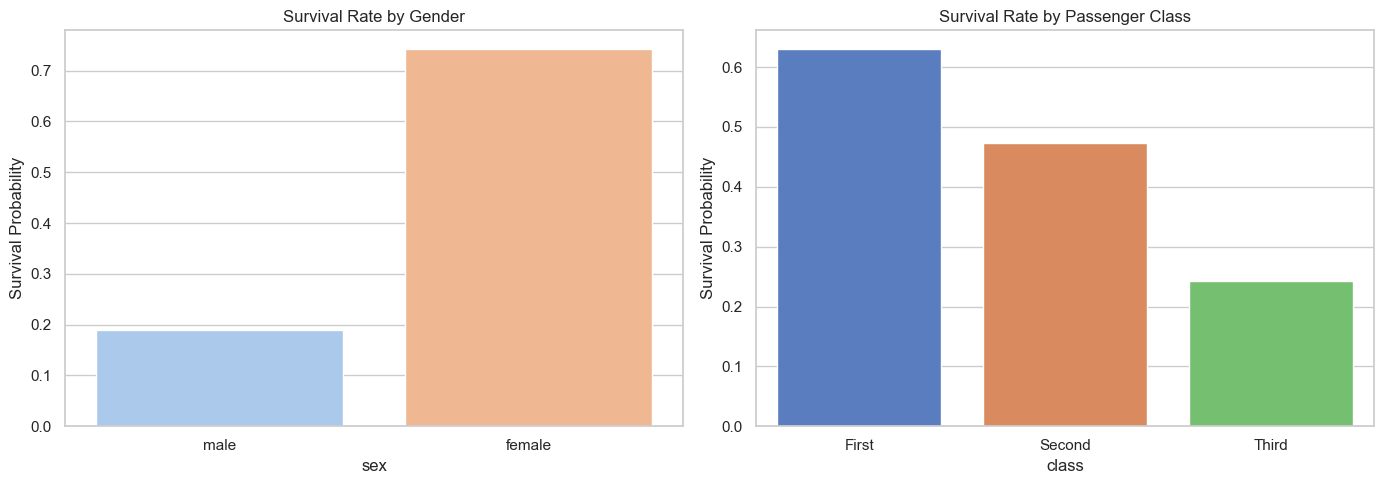

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Survival by Gender
sns.barplot(data=df, x='sex', y='survived', palette='pastel', ax=axes[0], errorbar=None)
axes[0].set_title('Survival Rate by Gender')
axes[0].set_ylabel('Survival Probability')

# Plot 2: Survival by Passenger Class
sns.barplot(data=df, x='class', y='survived', palette='muted', ax=axes[1], errorbar=None)
axes[1].set_title('Survival Rate by Passenger Class')
axes[1].set_ylabel('Survival Probability')

plt.tight_layout()
plt.show()

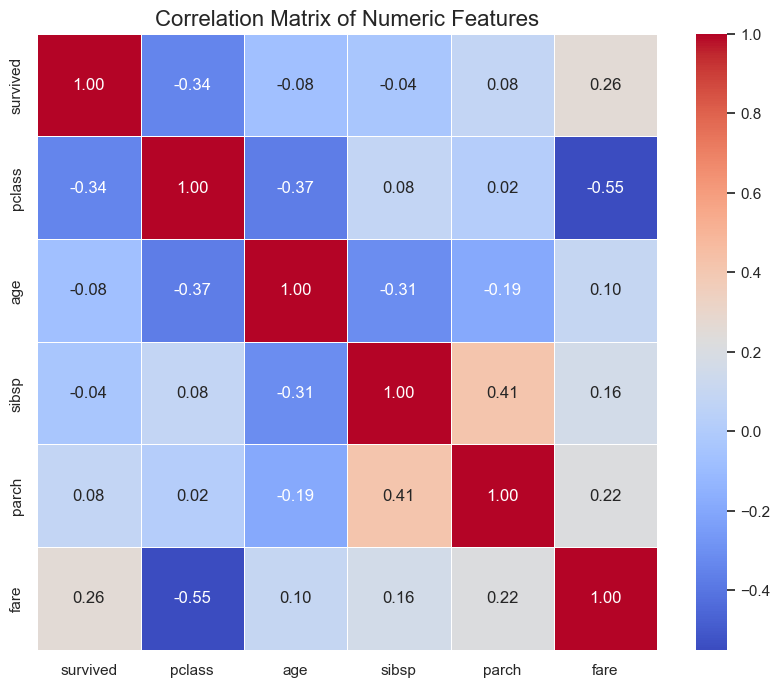

In [22]:
plt.figure(figsize=(10, 8))

# Select only numeric columns for correlation matrix
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

# Create a heatmap to visualize correlations
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features', fontsize=16)
plt.show()